# Desafio de Churn - G4

## Carga de dados

In [117]:
# Deep LEarning / ML
import numpy as np
import torch
import torch.nn as nn
from torchsummary import summary
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# EDA
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ML Ops
import mlflow
import mlflow.pytorch

In [118]:
df_accounts = pd.read_csv("dataset/ravenstack_accounts.csv")
df_accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [119]:
df_events = pd.read_csv("dataset/ravenstack_churn_events.csv")
df_events

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive
...,...,...,...,...,...,...,...,...,...
595,C-b56a35,A-702032,2024-06-14,competitor,0.00,False,False,False,switched to competitor
596,C-7e7822,A-dbc825,2024-02-03,budget,0.00,False,False,False,NaN
597,C-484fba,A-0a282f,2024-12-31,support,62.66,False,True,False,too expensive
598,C-22f536,A-e5d6ab,2024-05-11,competitor,0.00,True,False,False,NaN


In [120]:
df_feature_usage = pd.read_csv("dataset/ravenstack_feature_usage.csv")
df_feature_usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [121]:
df_subscriptions = pd.read_csv("dataset/ravenstack_subscriptions.csv")
df_subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [122]:
df_support_tickets = pd.read_csv("dataset/ravenstack_support_tickets.csv")
df_support_tickets.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


## Entendendo df de accounts

In [123]:
df_accounts.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 57.2 KB


In [124]:
account_cols = df_accounts.select_dtypes(include='str').columns.tolist()
account_cols.extend(["seats", "is_trial"])

In [125]:
# transformando signup_date em datetime
df_accounts["signup_date"] = pd.to_datetime(df_accounts["signup_date"])

In [126]:
# Analisando distribuição de churns por colunas str com % de proporção de churns
for column in df_accounts.select_dtypes(include='object').columns:
    if column in ["account_id", "signup_date", "account_name"]:
        continue
    fig = px.histogram(df_accounts, x=column, color="churn_flag", barmode="group", barnorm="percent", text_auto=".2f", title=f"Distribuição de churns por {column}")
    fig.show()

C:\Users\User\AppData\Local\Temp\ipykernel_32560\2381172351.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_accounts.select_dtypes(include='object').columns:


In [127]:
# Teste de hipótese para colunas do df (exceto ids)
from scipy.stats import mannwhitneyu

def test_chi2(df, target_col, ignore_columns=[]):

    for column in df.columns.tolist():
        if "_id" in column:
            continue

        if target_col in column:
            continue

        if column in ignore_columns:
            continue

        if df[column].dtype in ["datetime64[us]", "datetime64[ns]"]:
            continue

        if df[column].dtype in ["int64", "float64"]:
            # calculando a correlação de Mann-Whitney
            churned = df[df[target_col] == 1][column]
            not_churned = df[df[target_col] == 0][column]
            stat, p = mannwhitneyu(churned, not_churned)
            if p < 0.05:
                print(f"A coluna '{column}' tem uma relação significativa com a variável '{target_col}' (p-value: {p:.4f})")
            else:
                print(f"A coluna '{column}' não tem uma relação significativa com a variável '{target_col}' (p-value: {p:.4f})")
            continue

        contingency_table = pd.crosstab(df[column], df[target_col])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        if p < 0.05:
            print(f"A coluna '{column}' tem uma relação significativa com a variável '{target_col}' (p-value: {p:.4f})")
        else:
            print(f"A coluna '{column}' não tem uma relação significativa com a variável '{target_col}' (p-value: {p:.4f})")


In [128]:
test_chi2(df_accounts, "churn_flag")

A coluna 'account_name' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.4790)
A coluna 'industry' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.0657)
A coluna 'country' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.6588)
A coluna 'referral_source' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.0794)
A coluna 'plan_tier' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.9993)
A coluna 'seats' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.6919)
A coluna 'is_trial' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.3883)


Nenhuma característica da conta explica o churn de forma estatisticamente significativa. DevTools tem a maior taxa de churn (31% contra 22% na média) e o canal event também se destaca (30% contra 15% de partner). Mas os testes qui-quadrado não passam de 5% (industry p ≈ 0,07; referral_source p ≈ 0,08). Os 32% da Alemanha vêm de apenas 25 contas (p ≈ 0,66), ou seja, é ruído. O plano não faz diferença nenhuma (~22% nos três, p ≈ 1,0).
Leitura: existem indícios em indústria e canal, mas nada que justifique ação isolada. Ficam como hipóteses para cruzar com outros fatores.

## Analisando df de eventos com accounts

In [129]:
df_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    str    
 1   account_id                600 non-null    str    
 2   churn_date                600 non-null    str    
 3   reason_code               600 non-null    str    
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    str    
dtypes: bool(3), float64(1), str(5)
memory usage: 57.1 KB


In [130]:
# convertendo as datas para o tipo datetime
df_events["churn_date"] = pd.to_datetime(df_events["churn_date"])

In [131]:
# concatenando os dataframes em um único dataframe
df = df_events.merge(df_accounts[["account_id", "churn_flag"]], on="account_id", how="left")
df

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text,churn_flag
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor,False
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN,False
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features,True
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor,True
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive,False
...,...,...,...,...,...,...,...,...,...,...
595,C-b56a35,A-702032,2024-06-14,competitor,0.00,False,False,False,switched to competitor,False
596,C-7e7822,A-dbc825,2024-02-03,budget,0.00,False,False,False,NaN,False
597,C-484fba,A-0a282f,2024-12-31,support,62.66,False,True,False,too expensive,False
598,C-22f536,A-e5d6ab,2024-05-11,competitor,0.00,True,False,False,NaN,False


In [132]:
# Analisando distribuição de churns por colunas numéricas
for column in df.columns.tolist():
    if column in ["churn_event_id", "account_id", "churn_date"]:
        continue
    
    fig = px.histogram(df, x=column, color="churn_flag", barmode="group", barnorm="percent", text_auto=".2f", title=f"Distribuição de churns por {column}")
    fig.show()

In [133]:
# Box de colunas numéricas com churn_flag
for column in df.select_dtypes(include='number').columns.tolist():
    fig = px.box(df, x="churn_flag", y=column, color="churn_flag", title=f"Boxplot de {column} por churn_flag")
    fig.show()

In [134]:
# teste de hipóteses
test_chi2(df, "churn_flag")

A coluna 'reason_code' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.2512)
A coluna 'refund_amount_usd' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.5363)
A coluna 'preceding_upgrade_flag' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.7760)
A coluna 'preceding_downgrade_flag' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.3750)
A coluna 'is_reactivation' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.9420)
A coluna 'feedback_text' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.0520)


A tabela de eventos de churn é pouco confiável para explicar causa.

Inconsistência de definição: a maioria dos eventos de churn pertence a contas marcadas como churn_flag = False. A flag da conta e os eventos medem coisas diferentes, e as contas "churnadas" continuam com assinaturas ativas. O que a empresa perde é receita dentro de contas ativas, não clientes inteiros.
Motivos pulverizados: os seis reason_code aparecem em proporções parecidas (15% a 19% cada), e ~16% são unknown. O feedback_text não bate com o reason_code: quem marca "suporte" escreve "caro" com a mesma frequência que os outros.
Reembolsos são irrelevantes financeiramente: ~US$ 8,6 mil no total.
O número de eventos cresce no tempo, mas a base também cresceu. Contagem absoluta não prova aumento de churn; a taxa por coorte está na seção de importâncias.
Leitura: o formulário de saída não serve para decidir nada. Consertar a coleta do motivo de churn é uma recomendação por si só.

## Analisando df subscriptions

In [135]:
df_subscriptions.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   subscription_id    5000 non-null   str  
 1   account_id         5000 non-null   str  
 2   start_date         5000 non-null   str  
 3   end_date           486 non-null    str  
 4   plan_tier          5000 non-null   str  
 5   seats              5000 non-null   int64
 6   mrr_amount         5000 non-null   int64
 7   arr_amount         5000 non-null   int64
 8   is_trial           5000 non-null   bool 
 9   upgrade_flag       5000 non-null   bool 
 10  downgrade_flag     5000 non-null   bool 
 11  churn_flag         5000 non-null   bool 
 12  billing_frequency  5000 non-null   str  
 13  auto_renew_flag    5000 non-null   bool 
dtypes: bool(5), int64(3), str(6)
memory usage: 569.7 KB


In [136]:
# transformando datas em datetime
df_subscriptions["start_date"] = pd.to_datetime(df_subscriptions["start_date"])
df_subscriptions["end_date"] = pd.to_datetime(df_subscriptions["end_date"])

In [137]:
# Analisando plan_tier com churn_flag
fig = px.histogram(df_subscriptions, x="plan_tier", color="churn_flag", barmode="group", barnorm="percent", text_auto=".2f", title="Distribuição de churns por plan_tier")
fig.show()

In [138]:
# distribuição das bools com churn_flag
for column in df_subscriptions.select_dtypes(include='bool').columns.tolist():
    if column in ["subscription_id", "account_id", "start_date", "end_date"]:
        continue
    fig = px.histogram(df_subscriptions, x=column, color="churn_flag", barmode="group", barnorm="percent", text_auto=".2f", title=f"Distribuição de churns por {column}")
    fig.show()

In [139]:
# Distribuição de colunas numéricas com churn_flag
for column in df_subscriptions.select_dtypes(include='number').columns.tolist():
    fig = px.box(df_subscriptions, x="churn_flag", y=column, color="churn_flag", title=f"Boxplot de {column} por churn_flag")
    fig.show()

In [140]:
test_chi2(df_subscriptions, "churn_flag")

A coluna 'plan_tier' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.8878)
A coluna 'seats' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.5569)
A coluna 'mrr_amount' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.8978)
A coluna 'arr_amount' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.8978)
A coluna 'is_trial' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.8046)
A coluna 'upgrade_flag' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.4452)
A coluna 'downgrade_flag' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.4390)
A coluna 'billing_frequency' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.4863)
A coluna 'auto_renew_flag' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.9796)


Nenhuma variável parece contribuir diretamente pro churn. As distribuições são bastante proporcionais e medianas das numéricas também. Isso indica que não há disparidade *aparente* entre churn ou não.

## analisando df_feature_usage

In [141]:
df_feature_usage.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   usage_id             25000 non-null  str  
 1   subscription_id      25000 non-null  str  
 2   usage_date           25000 non-null  str  
 3   feature_name         25000 non-null  str  
 4   usage_count          25000 non-null  int64
 5   usage_duration_secs  25000 non-null  int64
 6   error_count          25000 non-null  int64
 7   is_beta_feature      25000 non-null  bool 
dtypes: bool(1), int64(3), str(4)
memory usage: 2.2 MB


In [142]:
# transformando datas em datetime
df_feature_usage["usage_date"] = pd.to_datetime(df_feature_usage["usage_date"])

In [143]:
# Juntando com df_subscriptions para analisar churn_flag
df_feature_usage_merged = df_feature_usage.merge(df_subscriptions[["account_id", "churn_flag", "subscription_id"]], on="subscription_id", how="left")
df_feature_usage_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   usage_id             25000 non-null  str           
 1   subscription_id      25000 non-null  str           
 2   usage_date           25000 non-null  datetime64[us]
 3   feature_name         25000 non-null  str           
 4   usage_count          25000 non-null  int64         
 5   usage_duration_secs  25000 non-null  int64         
 6   error_count          25000 non-null  int64         
 7   is_beta_feature      25000 non-null  bool          
 8   account_id           25000 non-null  str           
 9   churn_flag           25000 non-null  bool          
dtypes: bool(2), datetime64[us](1), int64(3), str(4)
memory usage: 2.4 MB


In [144]:
# Box de colunas numéricas com churn_flag
for column in df_feature_usage_merged.select_dtypes(include='number').columns.tolist():
    fig = px.box(df_feature_usage_merged, x="churn_flag", y=column, color="churn_flag", title=f"Boxplot de {column} por churn_flag")
    fig.show()

In [145]:
test_chi2(df_feature_usage_merged, "churn_flag")

A coluna 'feature_name' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.2771)
A coluna 'usage_count' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.7946)
A coluna 'usage_duration_secs' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.7934)
A coluna 'error_count' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.7144)
A coluna 'is_beta_feature' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.9444)


Ainda nenhuma correlação forte isoladamente. Medianas estão bastante pareada entre as classes de churn

## Analisando tickets

In [146]:
df_support_tickets.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ticket_id                    2000 non-null   str    
 1   account_id                   2000 non-null   str    
 2   submitted_at                 2000 non-null   str    
 3   closed_at                    2000 non-null   str    
 4   resolution_time_hours        2000 non-null   float64
 5   priority                     2000 non-null   str    
 6   first_response_time_minutes  2000 non-null   int64  
 7   satisfaction_score           1175 non-null   float64
 8   escalation_flag              2000 non-null   bool   
dtypes: bool(1), float64(2), int64(1), str(5)
memory usage: 224.3 KB


In [147]:
df_support_tickets.describe()

,resolution_time_hours,first_response_time_minutes,satisfaction_score
count,2000.000000,2000.000000,1175.000000
mean,35.861000,88.480000,3.981277
std,21.138427,51.531877,0.809646
min,1.000000,1.000000,3.000000
25%,17.000000,43.000000,3.000000
50%,35.000000,88.000000,4.000000
75%,54.000000,131.000000,5.000000
max,72.000000,180.000000,5.000000


In [148]:
# transformando datas em datetime
df_support_tickets["submitted_at"] = pd.to_datetime(df_support_tickets["submitted_at"])
df_support_tickets["closed_at"] = pd.to_datetime(df_support_tickets["closed_at"])

In [149]:
# Merge com accounts para analisar churn_flag
df_support_tickets_merged = df_support_tickets.merge(df_accounts[["account_id", "churn_flag"]], on="account_id", how="left")

In [150]:
# Distribuição de churns por feature_usage
for column in df_support_tickets_merged.select_dtypes(include='str').columns:
    if column in ["ticket_id", "account_id", "submitted_at", "closed_at"]:
        continue
    fig = px.histogram(df_support_tickets_merged, x=column, color="churn_flag", barmode="group", barnorm="percent", text_auto=".2f", title=f"Distribuição de churns por {column}")
    fig.show()

In [151]:
#Box de colunas numéricas com churn_flag
for column in df_support_tickets_merged.select_dtypes(include='number').columns.tolist():
    fig = px.box(df_support_tickets_merged, x="churn_flag", y=column, color="churn_flag", title=f"Boxplot de {column} por churn_flag")
    fig.show()

In [152]:
test_chi2(df_support_tickets_merged, "churn_flag")

A coluna 'resolution_time_hours' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.8236)
A coluna 'priority' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.3468)
A coluna 'first_response_time_minutes' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.0938)
A coluna 'satisfaction_score' não tem uma relação significativa com a variável 'churn_flag' (p-value: nan)
A coluna 'escalation_flag' não tem uma relação significativa com a variável 'churn_flag' (p-value: 0.4465)


Síntese: olhando as variáveis uma a uma nas 5 tabelas, nenhuma separa quem churna de quem fica.

Contas: indústria e canal têm indícios, mas não são significativos (p ≈ 0,07–0,08).
Assinaturas: plano, billing, auto-renew, trial, seats e MRR não diferem.
Uso: contagem, duração e erros são praticamente idênticos entre os grupos.
Suporte: tempo de resolução, primeira resposta (Mann-Whitney p ≈ 0,09) e satisfação não diferem. A satisfação tem ~41% de respostas vazias, então o "satisfação ok" do CS se apoia numa métrica incompleta.
Conclusão: o churn não é explicado por quem o cliente é nem por como ele usa o produto. A pista está no quando, investigado a seguir.

## Análises de importâncias

In [153]:
# Converter start_date em meses e trimestes e plotar churn_flag por mês e trimestre
df_subscriptions["start_month"] = df_subscriptions["start_date"].dt.to_period("M").astype(str)
df_subscriptions["start_quarter"] = df_subscriptions["start_date"].dt.to_period("Q").astype(str)

In [154]:
df_subscriptions.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    5000 non-null   str           
 1   account_id         5000 non-null   str           
 2   start_date         5000 non-null   datetime64[us]
 3   end_date           486 non-null    datetime64[us]
 4   plan_tier          5000 non-null   str           
 5   seats              5000 non-null   int64         
 6   mrr_amount         5000 non-null   int64         
 7   arr_amount         5000 non-null   int64         
 8   is_trial           5000 non-null   bool          
 9   upgrade_flag       5000 non-null   bool          
 10  downgrade_flag     5000 non-null   bool          
 11  churn_flag         5000 non-null   bool          
 12  billing_frequency  5000 non-null   str           
 13  auto_renew_flag    5000 non-null   bool          
 14  start_month        

In [155]:
# plotando churn_flag por mês
taxa = df_subscriptions.groupby("start_quarter")["churn_flag"].agg(["mean", "size"]).reset_index()
fig = px.bar(taxa, x="start_quarter", y="size", text="size", title="Número de assinaturas por trimestre")
fig.show()

In [156]:
# Analisando tempo entre churn e ingresso pra entender se estamos perdendo mais clientes novos ou antigos
df_subscriptions["days_to_churn"] = (df_subscriptions["end_date"] - df_subscriptions["start_date"]).dt.days

In [157]:
df_subscriptions

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,start_month,start_quarter,days_to_churn
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True,2023-12,2023Q4,111.0
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True,2024-06,2024Q2,NaN
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False,2024-11,2024Q4,NaN
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,2024-11,2024Q4,20.0
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True,2024-01,2024Q1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S-c158df,A-fa2041,2024-10-27,NaT,Enterprise,18,3582,42984,False,False,False,False,monthly,True,2024-10,2024Q4,NaN
4996,S-b49c0a,A-db5e9e,2024-12-05,NaT,Pro,23,1127,13524,False,False,False,False,monthly,False,2024-12,2024Q4,NaN
4997,S-42822d,A-443f6f,2024-12-15,NaT,Pro,25,1225,14700,False,False,False,False,annual,True,2024-12,2024Q4,NaN
4998,S-432401,A-c7ffc2,2023-05-25,NaT,Pro,132,6468,77616,False,False,False,False,monthly,True,2023-05,2023Q2,NaN


In [158]:
churned = df_subscriptions[df_subscriptions["churn_flag"]]
fig = px.histogram(churned, x="days_to_churn", nbins=40,
                   title="Em quantos dias as assinaturas cancelam?")
fig.show()

In [159]:
N = [30,60,90]

for n in N:
    corte = df_subscriptions["start_date"].max() - pd.Timedelta(days=n)

    elegiveis = df_subscriptions[df_subscriptions["start_date"] <= corte].copy()
    elegiveis[f"churn_{n}d"] = elegiveis["days_to_churn"] <= n   # NaN (ativos) vira False

    taxa = elegiveis.groupby("start_quarter")[f"churn_{n}d"].agg(["mean", "size"]).reset_index()
    fig = px.bar(taxa, x="start_quarter", y="mean", text="size",
                title=f"% de assinaturas que cancelaram em até {n} dias, por coorte")
    fig.update_layout(yaxis_tickformat=".1%")
    fig.show()

## Juntando os DFs para começar análises mais profundas

In [160]:
df_feature_usage.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   usage_id             25000 non-null  str           
 1   subscription_id      25000 non-null  str           
 2   usage_date           25000 non-null  datetime64[us]
 3   feature_name         25000 non-null  str           
 4   usage_count          25000 non-null  int64         
 5   usage_duration_secs  25000 non-null  int64         
 6   error_count          25000 non-null  int64         
 7   is_beta_feature      25000 non-null  bool          
dtypes: bool(1), datetime64[us](1), int64(3), str(3)
memory usage: 2.0 MB


In [161]:
# Juntando dfs sem groupby, para ter todas as features em um único df
df_total = df_subscriptions.merge(df_accounts[["account_id", "industry", "country", "referral_source",
                 "plan_tier", "seats", "is_trial", "churn_flag"]], on="account_id", how="left", suffixes=("", "_acct"))

In [162]:
# Uso SOMENTE nos primeiros 30 dias de cada assinatura
uso = df_feature_usage.merge(df_subscriptions[["subscription_id", "start_date"]], on="subscription_id")
uso = uso[(uso["usage_date"] >= uso["start_date"]) &
          (uso["usage_date"] <= uso["start_date"] + pd.Timedelta(days=30))]

In [163]:
uso_agg = uso.groupby("subscription_id").agg(
    uso_30d_eventos=("usage_id", "count"),
    uso_30d_count=("usage_count", "sum"),
    uso_30d_duracao=("usage_duration_secs", "sum"),
    uso_30d_erros=("error_count", "sum"),
    uso_30d_features=("feature_name", "nunique"),
).reset_index()

In [164]:
df_total = df_total.merge(uso_agg, on="subscription_id", how="left")
cols_uso = [c for c in df_total.columns if c.startswith("uso_30d")]
df_total[cols_uso] = df_total[cols_uso].fillna(0)   # sem uso = 0, não NaN

print(len(df_total) == len(df_subscriptions))

True


In [165]:
df_total

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,referral_source,plan_tier_acct,seats_acct,is_trial_acct,churn_flag_acct,uso_30d_eventos,uso_30d_count,uso_30d_duracao,uso_30d_erros,uso_30d_features
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,...,event,Pro,1,False,False,0.0,0.0,0.0,0.0,0.0
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,...,other,Basic,5,False,False,1.0,13.0,2457.0,3.0,1.0
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,...,event,Enterprise,13,True,True,1.0,8.0,4480.0,1.0,1.0
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,...,event,Enterprise,3,False,False,1.0,13.0,3861.0,2.0,1.0
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,...,ads,Pro,27,False,False,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,S-c158df,A-fa2041,2024-10-27,NaT,Enterprise,18,3582,42984,False,False,...,organic,Pro,15,True,False,0.0,0.0,0.0,0.0,0.0
4996,S-b49c0a,A-db5e9e,2024-12-05,NaT,Pro,23,1127,13524,False,False,...,partner,Basic,4,False,False,1.0,8.0,1440.0,2.0,1.0
4997,S-42822d,A-443f6f,2024-12-15,NaT,Pro,25,1225,14700,False,False,...,organic,Basic,19,False,False,0.0,0.0,0.0,0.0,0.0
4998,S-432401,A-c7ffc2,2023-05-25,NaT,Pro,132,6468,77616,False,False,...,partner,Pro,30,True,False,0.0,0.0,0.0,0.0,0.0


In [166]:
# Quem são os clientes que cancelam em até 30 dias? Analisando churn_30d por plan_tier
elegiveis = df_total[df_total["start_date"] <= (df_total["start_date"].max() - pd.Timedelta(days=30))].copy()
elegiveis["churn_30d"] = elegiveis["days_to_churn"] <= 30   # NaN (ativos) vira False
elegiveis

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,plan_tier_acct,seats_acct,is_trial_acct,churn_flag_acct,uso_30d_eventos,uso_30d_count,uso_30d_duracao,uso_30d_erros,uso_30d_features,churn_30d
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,...,Pro,1,False,False,0.0,0.0,0.0,0.0,0.0,False
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,...,Basic,5,False,False,1.0,13.0,2457.0,3.0,1.0,False
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,...,Enterprise,13,True,True,1.0,8.0,4480.0,1.0,1.0,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,...,Enterprise,3,False,False,1.0,13.0,3861.0,2.0,1.0,True
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,...,Pro,27,False,False,0.0,0.0,0.0,0.0,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4991,S-4b9226,A-798a3f,2024-10-11,NaT,Enterprise,13,2587,31044,False,False,...,Enterprise,12,False,True,0.0,0.0,0.0,0.0,0.0,False
4992,S-72fa62,A-4c56c9,2024-09-03,NaT,Enterprise,27,5373,64476,False,False,...,Enterprise,9,False,True,0.0,0.0,0.0,0.0,0.0,False
4994,S-7c635b,A-92a333,2023-08-15,NaT,Enterprise,33,6567,78804,False,False,...,Enterprise,9,False,False,0.0,0.0,0.0,0.0,0.0,False
4995,S-c158df,A-fa2041,2024-10-27,NaT,Enterprise,18,3582,42984,False,False,...,Pro,15,True,False,0.0,0.0,0.0,0.0,0.0,False


In [167]:
# Comparando plan_tier com churn_30d
fig = px.histogram(elegiveis, x="plan_tier", color="churn_30d", barmode="group", barnorm="percent", text_auto=".2f", title="Distribuição de churns em até 30 dias por plan_tier")
fig.show()

In [168]:
# comparando billing_frequency com churn_30d
fig = px.histogram(elegiveis, x="billing_frequency", color="churn_30d", barmode="group", barnorm="percent", text_auto=".2f", title="Distribuição de churns em até 30 dias por billing_frequency")
fig.show()

In [169]:
# Comparando is_trial com churn_30d
fig = px.histogram(elegiveis, x="is_trial", color="churn_30d", barmode="group", barnorm="percent", text_auto=".2f", title="Distribuição de churns em até 30 dias por is_trial")
fig.show()

In [170]:
# Seats com churn_30d
fig = px.box(elegiveis, x="churn_30d", y="seats", color="churn_30d", title="Boxplot de seats por churn_30d")
fig.show()

In [171]:
# Comparando auto_renew_flag com churn_30d
fig = px.histogram(elegiveis, x="auto_renew_flag", color="churn_30d", barmode="group", barnorm="percent", text_auto=".2f", title="Distribuição de churns em até 30 dias por auto_renew_flag")
fig.show()

In [172]:
elegiveis.info()

<class 'pandas.DataFrame'>
Index: 4066 entries, 0 to 4998
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscription_id    4066 non-null   str           
 1   account_id         4066 non-null   str           
 2   start_date         4066 non-null   datetime64[us]
 3   end_date           386 non-null    datetime64[us]
 4   plan_tier          4066 non-null   str           
 5   seats              4066 non-null   int64         
 6   mrr_amount         4066 non-null   int64         
 7   arr_amount         4066 non-null   int64         
 8   is_trial           4066 non-null   bool          
 9   upgrade_flag       4066 non-null   bool          
 10  downgrade_flag     4066 non-null   bool          
 11  churn_flag         4066 non-null   bool          
 12  billing_frequency  4066 non-null   str           
 13  auto_renew_flag    4066 non-null   bool          
 14  start_month        4066 

In [173]:
# Comparando industry com churn_30d
fig = px.histogram(elegiveis, x="industry", color="churn_30d", barmode="group", barnorm="percent", text_auto=".2f", title="Distribuição de churns em até 30 dias por industry")
fig.show()

In [174]:
# Comparando referral_source com churn_30d
fig = px.histogram(elegiveis, x="referral_source", color="churn_30d", barmode="group", barnorm="percent", text_auto=".2f", title="Distribuição de churns em até 30 dias por referral_source")
fig.show()

In [175]:
# Comparando country com churn_30d
fig = px.histogram(elegiveis, x="country", color="churn_30d", barmode="group", barnorm="percent", text_auto=".2f", title="Distribuição de churns em até 30 dias por country")
fig.show()

In [176]:
test_chi2(elegiveis, "churn_30d", ignore_columns=["start_date", "end_date", "days_to_churn", "churn_flag"])

A coluna 'plan_tier' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.7724)
A coluna 'seats' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.4457)
A coluna 'mrr_amount' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.7927)
A coluna 'arr_amount' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.7927)
A coluna 'is_trial' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.6981)
A coluna 'upgrade_flag' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.9112)
A coluna 'downgrade_flag' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.6823)
A coluna 'billing_frequency' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.6355)
A coluna 'auto_renew_flag' não tem uma relação significativa com a variável 'churn_30d' (p-value: 0.8048)
A coluna 'start_month' tem uma relação significativa com a variável 'churn_30d' (

In [177]:
# Analisando seats_acct com p = 0,006.
# Boxplot de seats_acct com churn_30d
fig = px.box(elegiveis, x="churn_30d", y="seats_acct", color="churn_30d", title="Boxplot de seats por churn_30d")
fig.show()

In [178]:
(elegiveis["uso_30d_eventos"] == 0).mean()

np.float64(0.8034923757993113)

In [179]:
(elegiveis["churn_30d"]).sum()

np.int64(108)

In [180]:
por_conta = elegiveis.groupby("account_id").agg(
    teve_churn_30d=("churn_30d", "any"),
    seats_acct=("seats_acct", "first"),
).reset_index()

print(por_conta["teve_churn_30d"].sum(), "contas com churn em 30d de", len(por_conta))
print(por_conta.groupby("teve_churn_30d")["seats_acct"].median())
print(mannwhitneyu(por_conta.loc[por_conta.teve_churn_30d, "seats_acct"],
                   por_conta.loc[~por_conta.teve_churn_30d, "seats_acct"]))

101 contas com churn em 30d de 476
teve_churn_30d
False    16.0
True      9.0
Name: seats_acct, dtype: float64
MannwhitneyuResult(statistic=np.float64(14927.5), pvalue=np.float64(0.0010771370648268578))


In [181]:
# 1 linha por conta: se teve churn em 30d, quantas assinaturas elegíveis tem, e os seats
por_conta = elegiveis.groupby("account_id").agg(
    teve_churn_30d=("churn_30d", "any"),
    n_assinaturas=("subscription_id", "count"),
    seats_acct=("seats_acct", "first"),
).reset_index()

In [182]:
# Divide as contas em 4 faixas de tamanho (quartis de seats)
por_conta["faixa_seats"] = pd.qcut(por_conta["seats_acct"], 4, labels=["1) 1-6 seats", "2) 7-15 seats", "3) 16-28 seats", "4) 29+ seats"]).astype(str)

resumo = por_conta.groupby("faixa_seats").agg(
    contas=("account_id", "count"),
    pct_churn_30d=("teve_churn_30d", "mean"),
    media_assinaturas=("n_assinaturas", "mean"),   # checagem do viés de exposição
).reset_index()
print(resumo)

      faixa_seats  contas  pct_churn_30d  media_assinaturas
0    1) 1-6 seats     129       0.302326           8.682171
1   2) 7-15 seats     116       0.215517           8.913793
2  3) 16-28 seats     112       0.160714           8.741071
3    4) 29+ seats     119       0.159664           7.840336


In [183]:
# Dose-resposta: o % cai conforme a conta cresce?
fig = px.bar(resumo, x="faixa_seats", y="pct_churn_30d", text="contas",
             title="% de contas com churn em até 30 dias, por tamanho da conta (seats)")
fig.update_layout(yaxis_tickformat=".0%", xaxis_title="Faixa de seats da conta")
fig.show()

Contas pequenas perdem assinaturas mais cedo. Entre as contas elegíveis, as que tiveram churn em até 30 dias têm mediana de [9] seats, contra [16] das demais (Mann-Whitney, p = [0,001], 1 linha por conta).
Confiabilidade: o resultado se mantém após correção de Bonferroni (limite 0,002 para ~25 testes) e não é explicado por número de assinaturas, que é parecido entre as faixas ([8–9]). Há dose-resposta: []% das menores contas (até [6] seats) tiveram churn em 30 dias, contra []% das maiores.
Limitação: são [101] contas com churn em 30 dias, o que é base pequena. É associação, não causa.
Hipótese de negócio: contas pequenas provavelmente recebem menos atenção no onboarding. Vale testar um onboarding específico para contas com menos de [X] seats antes de escalar.

In [184]:
# MRR perdida nas assinaturas que cancelaram em até 30 dias, por coorte
mrr_coorte = elegiveis.groupby("start_quarter").agg(
    mrr_nova=("mrr_amount", "sum"),
    mrr_perdida_30d=("mrr_amount", lambda x: x[elegiveis.loc[x.index, "churn_30d"]].sum()),
).reset_index()
mrr_coorte["pct_mrr_perdida_30d"] = mrr_coorte["mrr_perdida_30d"] / mrr_coorte["mrr_nova"]
print(mrr_coorte)

  start_quarter  mrr_nova  mrr_perdida_30d  pct_mrr_perdida_30d
0        2023Q1     41648                0             0.000000
1        2023Q2    202694              245             0.001209
2        2023Q3    402265             2923             0.007266
3        2023Q4    667001             4299             0.006445
4        2024Q1   1064291            17454             0.016400
5        2024Q2   1616165             5521             0.003416
6        2024Q3   2348608            50289             0.021412
7        2024Q4   2769182           157416             0.056846


In [185]:
# MRR total perdido em 2024/Q4 independente do start_date
perdas_q4  = df_subscriptions[(df_subscriptions["end_date"] >= "2024-10-01") & (df_subscriptions["end_date"] < "2025-01-01")]
mrr_perdida_2024Q4 = perdas_q4 .loc[perdas_q4 ["churn_flag"], "mrr_amount"].sum()
mrr_perdida_2024Q4

np.int64(871812)

In [186]:
# Quanto dessa perda veio de assinaturas novas vs. antigas
perdas_q4["idade_no_churn"] = pd.cut(perdas_q4["days_to_churn"],
                                     bins=[-1, 30, 90, 180, 10_000],
                                     labels=["até 30d", "31–90d", "91–180d", "180d+"])
tabela = perdas_q4.groupby("idade_no_churn", observed=True)["mrr_amount"].sum()
print(tabela)
print((tabela / tabela.sum()).round(3))

idade_no_churn
até 30d    436103
31–90d     215803
91–180d     85676
180d+      134230
Name: mrr_amount, dtype: int64
idade_no_churn
até 30d    0.500
31–90d     0.248
91–180d    0.098
180d+      0.154
Name: mrr_amount, dtype: float64


75% da receita perdida no Q4/24 veio de clientes com menos de 3 meses de casa. Dos US$ 872 mil de MRR perdida no trimestre, US$ 436 mil (50%) vieram de assinaturas canceladas em até 30 dias e US$ 216 mil (25%) de assinaturas entre 31 e 90 dias. 
Assinaturas com mais de 6 meses responderam por apenas 15%.

**Leitura**: o aumento do churn não é desgaste da base, é falha na entrada. Ou o onboarding não entrega valor rápido, ou a venda está trazendo clientes que não se encaixam no produto. O crescimento acelerado de novas assinaturas no segundo semestre de 2024 (célula 51) coincide com essa piora.

In [187]:
perdas_30d

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,start_month,start_quarter,days_to_churn,idade_no_churn
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True,2024-11,2024Q4,20.0,até 30d
21,S-3bd427,A-2e3bad,2024-12-04,2024-12-27,Basic,61,1159,13908,False,False,False,True,monthly,True,2024-12,2024Q4,23.0,até 30d
78,S-ce5450,A-0a282f,2024-12-25,2024-12-28,Pro,8,0,0,True,False,False,True,annual,True,2024-12,2024Q4,3.0,até 30d
124,S-1bd2ec,A-e60f9d,2024-12-25,2024-12-28,Basic,38,722,8664,False,False,False,True,annual,True,2024-12,2024Q4,3.0,até 30d
134,S-017e33,A-f9cc74,2024-11-08,2024-11-25,Basic,53,1007,12084,False,False,False,True,monthly,True,2024-11,2024Q4,17.0,até 30d
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4756,S-3b5eb3,A-6f8ad2,2024-10-07,2024-10-12,Pro,70,0,0,True,True,False,True,annual,True,2024-10,2024Q4,5.0,até 30d
4858,S-9d727d,A-ac85cd,2024-12-09,2024-12-18,Basic,53,0,0,True,False,False,True,monthly,True,2024-12,2024Q4,9.0,até 30d
4871,S-8442d1,A-82d8a6,2024-12-22,2024-12-24,Enterprise,21,0,0,True,False,False,True,monthly,True,2024-12,2024Q4,2.0,até 30d
4874,S-c7621b,A-ced9aa,2024-11-23,2024-11-25,Basic,19,361,4332,False,False,False,True,annual,True,2024-11,2024Q4,2.0,até 30d


In [188]:
# MRR perdida em até 30 dias por faixa de seats
base = elegiveis.merge(por_conta[["account_id", "faixa_seats"]], on="account_id", how="left")

mrr_faixa = base.groupby("faixa_seats", observed=True).agg(
    mrr_total=("mrr_amount", "sum"),
    mrr_perdida_30d=("mrr_amount", lambda x: x[base.loc[x.index, "churn_30d"]].sum()),
).reset_index()
mrr_faixa["pct_perdida"] = mrr_faixa["mrr_perdida_30d"] / mrr_faixa["mrr_total"]
mrr_faixa["share_da_perda"] = mrr_faixa["mrr_perdida_30d"] / mrr_faixa["mrr_perdida_30d"].sum()
print(mrr_faixa)

      faixa_seats  mrr_total  mrr_perdida_30d  pct_perdida  share_da_perda
0    1) 1-6 seats    1658050            80641     0.048636        0.338619
1   2) 7-15 seats    1817279            37508     0.020640        0.157499
2  3) 16-28 seats    2089669            54899     0.026272        0.230526
3    4) 29+ seats    3546856            65099     0.018354        0.273356


In [189]:
# Churn dos clientes que abriram tickets de suporte em até 30 dias
t = elegiveis[["subscription_id", "account_id", "start_date"]].merge(
    df_support_tickets, on="account_id", how="inner")
t = t[(t["submitted_at"] >= t["start_date"]) &
      (t["submitted_at"] <= t["start_date"] + pd.Timedelta(days=30))]

tick_agg = t.groupby("subscription_id").agg(
    tickets_30d=("ticket_id", "count"),
    escalados_30d=("escalation_flag", "sum"),
    satisf_30d=("satisfaction_score", "mean"),
).reset_index()

base = base.merge(tick_agg, on="subscription_id", how="left")
base[["tickets_30d", "escalados_30d"]] = base[["tickets_30d", "escalados_30d"]].fillna(0)
base["abriu_ticket_30d"] = base["tickets_30d"] > 0
assert len(base) == len(elegiveis)

# Quem abriu ticket nos primeiros 30 dias churna mais?
taxa = base.groupby("abriu_ticket_30d")["churn_30d"].agg(["mean", "size"]).reset_index()
fig = px.bar(taxa, x="abriu_ticket_30d", y="mean", text="size",
             title="% churn em 30 dias: abriu ticket vs. não abriu")
fig.update_layout(yaxis_tickformat=".1%")
fig.show()

## Síntese final: o que está causando o churn

### 1. O churn subiu porque clientes novos estão saindo cedo
- A MRR perdida no Q4/24 foi de **US$ 872 mil**. Desse total, **75% veio de assinaturas com até 90 dias** de vida (50% só nos primeiros 30 dias). Assinaturas com mais de 6 meses responderam por apenas 15%.
- Comparando coortes na mesma janela, o churn nos primeiros 30 dias ficou entre 0,6% e 1% até 2024Q2, subiu para 2,4% em 2024Q3 e chegou a **6,0% em 2024Q4**. Em receita, **5,7% da MRR nova do Q4 sumiu no primeiro mês** (US$ 157 mil/mês, cerca de US$ 1,9 milhão/ano).
- A piora coincide com a aceleração das vendas: o número de assinaturas novas por trimestre saltou de ~470 (2024Q1) para ~2.070 (2024Q4).

### 2. O perfil do cliente não explica, com uma exceção
- Plano, billing, trial, auto-renew, indústria, país e canal **não diferem** entre quem sai cedo e quem fica (todos com p > 0,05).
- **Exceção: tamanho da conta.** As contas com churn em 30 dias têm mediana de 9 seats, contra 16 das demais (Mann-Whitney p = 0,001, 1 linha por conta, robusto à correção de Bonferroni). Há dose-resposta: 30% das contas com 1 a 6 seats tiveram churn em 30 dias, contra 16% das contas com mais de 16 seats.
- **Em dinheiro:** as contas com 1 a 6 seats têm 18% da MRR, mas respondem por **34% da MRR perdida em 30 dias** (taxa de perda de 4,9%, contra 1,8% a 2,6% nas demais faixas). Mesmo assim, **dois terços da perda vêm de contas maiores.** Contas pequenas são uma parte do problema, não o problema inteiro.

### 3. Eles saem calados
- **~80% das assinaturas que cancelaram em 30 dias não abriram nenhum ticket** nesse período. A diferença de churn entre quem abriu e quem não abriu ticket (3,3% contra 2,5%) não é significativa (p ≈ [0,29]).
- **80% das assinaturas não têm nenhum registro de uso** nos primeiros 30 dias, então não dá para medir ativação com os dados atuais.

### 4. Por que os números "não batiam" para o CEO
- **"A satisfação está ok" (CS):** a métrica tem 41% de respostas vazias e só mede quem abre ticket. Quem sai cedo não abre.
- **"O uso cresceu" (Produto):** o uso agregado não enxerga a coorte nova, e a telemetria nem registra a maior parte dos primeiros 30 dias.
- **Motivo de saída:** o `reason_code` não bate com o `feedback_text`, e a flag de churn da conta contradiz a tabela de eventos.
- Os três painéis olham a base inteira. O problema está concentrado nos clientes recém-chegados, que nenhum deles recorta.

### Limitações
- O dataset é sintético. Várias variáveis se comportam como ruído aleatório.
- São 108 assinaturas (101 contas) com churn em 30 dias, uma base pequena para cortes mais finos.
- Os resultados são associações, não causas. O efeito do tamanho da conta e da aceleração das vendas precisa ser validado com teste controlado.
- A coorte 2024Q4 só inclui assinaturas iniciadas até 01/12/2024 (filtro de elegibilidade).

## Separando contas em risco e preparando dataet pra Machine Learning

In [190]:
# ===== Lista de assinaturas em risco (regra baseada nos achados) =====
data_ref = df_subscriptions["start_date"].max()          # "hoje" = fim do dataset
bins   = [0, 6, 15, 28, float("inf")]
labels = ["1) 1-6 seats", "2) 7-15 seats", "3) 16-28 seats", "4) 29+ seats"]

In [191]:
# 1) Probabilidade histórica de churn em 30d por faixa de seats (nível assinatura)
recentes = base[base["start_date"] >= "2024-07-01"]
prob_faixa = (recentes.groupby("faixa_seats", observed=True)["churn_30d"]
                  .mean().rename("prob_churn_30d").reset_index())
prob_faixa

,faixa_seats,prob_churn_30d
0,1) 1-6 seats,0.058537
1,2) 7-15 seats,0.040609
2,3) 16-28 seats,0.030189
3,4) 29+ seats,0.037549


In [192]:
# 2) Assinaturas ATIVAS com até 30 dias de vida
ativas = df_total[df_total["end_date"].isna()].copy()
ativas["idade_dias"] = (data_ref - ativas["start_date"]).dt.days
em_risco = ativas[ativas["idade_dias"] <= 30].copy()
em_risco["faixa_seats"] = pd.cut(em_risco["seats_acct"], bins=bins, labels=labels)

In [193]:
# 3) Perda esperada = probabilidade x MRR
em_risco = em_risco.merge(prob_faixa, on="faixa_seats", how="left")
em_risco["perda_esperada"] = em_risco["prob_churn_30d"] * em_risco["mrr_amount"]

In [194]:
# 4) Visão por CONTA (o CS liga para contas, não para assinaturas)
contas_risco = (em_risco.groupby(["account_id", "industry", "faixa_seats"], observed=True)
    .agg(assinaturas_novas=("subscription_id", "count"),
         mrr_em_jogo=("mrr_amount", "sum"),
         perda_esperada=("perda_esperada", "sum"))
    .reset_index()
    .sort_values("perda_esperada", ascending=False))

print(len(em_risco), "assinaturas |", len(contas_risco), "contas |",
      f"MRR em jogo: {em_risco['mrr_amount'].sum():,.0f} | perda esperada: {em_risco['perda_esperada'].sum():,.0f}")
contas_risco.head(20)

850 assinaturas | 319 contas | MRR em jogo: 1,979,879 | perda esperada: 81,131


,account_id,industry,faixa_seats,assinaturas_novas,mrr_em_jogo,perda_esperada
37,A-18793f,EdTech,4) 29+ seats,10,75776,2845.343874
21,A-0b0d6d,DevTools,1) 1-6 seats,11,30429,1781.209756
185,A-9174e0,Cybersecurity,4) 29+ seats,14,46613,1750.290514
190,A-956988,EdTech,1) 1-6 seats,12,29407,1721.385366
169,A-82d8a6,Cybersecurity,1) 1-6 seats,13,27626,1617.131707
116,A-5c046d,EdTech,4) 29+ seats,4,40548,1522.553360
246,A-c70870,Cybersecurity,4) 29+ seats,5,39025,1465.365613
65,A-39ddf4,EdTech,4) 29+ seats,8,33876,1272.023715
181,A-8bde0c,DevTools,2) 7-15 seats,14,31209,1267.370558
20,A-0aaf6e,FinTech,1) 1-6 seats,2,21094,1234.770732


In [195]:
# guardando csv de contas em risco
contas_risco.to_csv("./contas_em_risco.csv", index=False)

# Modelo de ML

In [196]:
df_model = base.copy()
df_model

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,uso_30d_count,uso_30d_duracao,uso_30d_erros,uso_30d_features,churn_30d,faixa_seats,tickets_30d,escalados_30d,satisf_30d,abriu_ticket_30d
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,...,0.0,0.0,0.0,0.0,False,1) 1-6 seats,0.0,0.0,NaN,False
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,...,13.0,2457.0,3.0,1.0,False,1) 1-6 seats,0.0,0.0,NaN,False
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,...,8.0,4480.0,1.0,1.0,False,2) 7-15 seats,0.0,0.0,NaN,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,...,13.0,3861.0,2.0,1.0,True,1) 1-6 seats,0.0,0.0,NaN,False
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,...,0.0,0.0,0.0,0.0,False,3) 16-28 seats,0.0,0.0,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4061,S-4b9226,A-798a3f,2024-10-11,NaT,Enterprise,13,2587,31044,False,False,...,0.0,0.0,0.0,0.0,False,2) 7-15 seats,1.0,0.0,4.0,True
4062,S-72fa62,A-4c56c9,2024-09-03,NaT,Enterprise,27,5373,64476,False,False,...,0.0,0.0,0.0,0.0,False,2) 7-15 seats,1.0,0.0,5.0,True
4063,S-7c635b,A-92a333,2023-08-15,NaT,Enterprise,33,6567,78804,False,False,...,0.0,0.0,0.0,0.0,False,2) 7-15 seats,0.0,0.0,NaN,False
4064,S-c158df,A-fa2041,2024-10-27,NaT,Enterprise,18,3582,42984,False,False,...,0.0,0.0,0.0,0.0,False,2) 7-15 seats,0.0,0.0,NaN,False


In [197]:
df_model = df_model.merge(df_accounts[["account_id", "signup_date"]], on="account_id", how="left")
df_model["tenure_conta_dias"] = (df_model["start_date"] - df_model["signup_date"]).dt.days
df_model

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,uso_30d_erros,uso_30d_features,churn_30d,faixa_seats,tickets_30d,escalados_30d,satisf_30d,abriu_ticket_30d,signup_date,tenure_conta_dias
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,...,0.0,0.0,False,1) 1-6 seats,0.0,0.0,NaN,False,2023-08-26,119
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,...,3.0,1.0,False,1) 1-6 seats,0.0,0.0,NaN,False,2023-09-28,257
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,...,1.0,1.0,False,2) 7-15 seats,0.0,0.0,NaN,False,2023-11-17,374
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,...,2.0,1.0,True,1) 1-6 seats,0.0,0.0,NaN,False,2024-06-23,153
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,...,0.0,0.0,False,3) 16-28 seats,0.0,0.0,NaN,False,2023-10-29,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4061,S-4b9226,A-798a3f,2024-10-11,NaT,Enterprise,13,2587,31044,False,False,...,0.0,0.0,False,2) 7-15 seats,1.0,0.0,4.0,True,2023-10-19,358
4062,S-72fa62,A-4c56c9,2024-09-03,NaT,Enterprise,27,5373,64476,False,False,...,0.0,0.0,False,2) 7-15 seats,1.0,0.0,5.0,True,2023-12-20,258
4063,S-7c635b,A-92a333,2023-08-15,NaT,Enterprise,33,6567,78804,False,False,...,0.0,0.0,False,2) 7-15 seats,0.0,0.0,NaN,False,2023-03-24,144
4064,S-c158df,A-fa2041,2024-10-27,NaT,Enterprise,18,3582,42984,False,False,...,0.0,0.0,False,2) 7-15 seats,0.0,0.0,NaN,False,2024-05-29,151


In [198]:
# Histórico da conta ANTES desta assinatura começar (sem olhar o futuro)
hist = df_model[["subscription_id", "account_id", "start_date"]].merge(
    df_subscriptions[["account_id", "start_date", "end_date", "churn_flag"]],
    on="account_id", suffixes=("", "_prev"))
hist = hist[hist["start_date_prev"] < hist["start_date"]]                  # começaram antes
hist["churn_antes"] = hist["churn_flag"] & (hist["end_date"] < hist["start_date"])  # e já tinham saído antes
hist_agg = hist.groupby("subscription_id").agg(
    n_assin_anteriores=("start_date_prev", "count"),
    n_churn_anteriores=("churn_antes", "sum")).reset_index()

hist_agg

,subscription_id,n_assin_anteriores,n_churn_anteriores
0,S-0027d3,5,1
1,S-003fc0,5,1
2,S-004d19,2,0
3,S-006908,7,0
4,S-006fed,3,0
...,...,...,...
3575,S-ffb6cc,10,1
3576,S-ffd1ee,9,0
3577,S-ffd591,2,0
3578,S-ffe125,4,0


In [199]:
df_model = df_model.merge(hist_agg, on="subscription_id", how="left")
df_model[["n_assin_anteriores", "n_churn_anteriores"]] = df_model[["n_assin_anteriores", "n_churn_anteriores"]].fillna(0)
df_model

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,...,churn_30d,faixa_seats,tickets_30d,escalados_30d,satisf_30d,abriu_ticket_30d,signup_date,tenure_conta_dias,n_assin_anteriores,n_churn_anteriores
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,...,False,1) 1-6 seats,0.0,0.0,NaN,False,2023-08-26,119,2.0,0.0
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,...,False,1) 1-6 seats,0.0,0.0,NaN,False,2023-09-28,257,6.0,1.0
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,...,False,2) 7-15 seats,0.0,0.0,NaN,False,2023-11-17,374,10.0,0.0
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,...,True,1) 1-6 seats,0.0,0.0,NaN,False,2024-06-23,153,9.0,0.0
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,...,False,3) 16-28 seats,0.0,0.0,NaN,False,2023-10-29,73,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4061,S-4b9226,A-798a3f,2024-10-11,NaT,Enterprise,13,2587,31044,False,False,...,False,2) 7-15 seats,1.0,0.0,4.0,True,2023-10-19,358,8.0,1.0
4062,S-72fa62,A-4c56c9,2024-09-03,NaT,Enterprise,27,5373,64476,False,False,...,False,2) 7-15 seats,1.0,0.0,5.0,True,2023-12-20,258,6.0,0.0
4063,S-7c635b,A-92a333,2023-08-15,NaT,Enterprise,33,6567,78804,False,False,...,False,2) 7-15 seats,0.0,0.0,NaN,False,2023-03-24,144,1.0,0.0
4064,S-c158df,A-fa2041,2024-10-27,NaT,Enterprise,18,3582,42984,False,False,...,False,2) 7-15 seats,0.0,0.0,NaN,False,2024-05-29,151,9.0,0.0


In [201]:
df_model["plan_tier"].value_counts()

plan_tier
Enterprise    1406
Pro           1334
Basic         1326
Name: count, dtype: int64

In [202]:
# transformando plan_tier em numérico (1=Basic, 2=Pro, 3=Enterprise)
df_model["plan_tier"] = df_model["plan_tier"].map({"Basic": 1, "Pro": 2, "Enterprise": 3}) #como começou a subscription
df_model["plan_tier_acct"] = df_model["plan_tier"].map({"Basic": 1, "Pro": 2, "Enterprise": 3}) # como está a conta hoje (pode ter feito upgrade ou downgrade)

In [203]:
num_cols = ["seats", "mrr_amount", "seats_acct", "tenure_conta_dias",
            "n_assin_anteriores", "n_churn_anteriores", "plan_tier", "plan_tier_acct"]
bool_cols = ["is_trial", "auto_renew_flag", "is_trial_acct"]
cat_cols = ["billing_frequency", "industry", "country",
            "referral_source"]

In [205]:
# prepadando df pra treino
X = pd.get_dummies(df_model[num_cols + bool_cols + cat_cols], columns=cat_cols, dtype=int, drop_first=True)
X[bool_cols] = X[bool_cols].astype(int)  # convertendo bools para int
y = df_model["churn_30d"].astype(int)  # target
X

,seats,mrr_amount,seats_acct,tenure_conta_dias,n_assin_anteriores,n_churn_anteriores,plan_tier,plan_tier_acct,is_trial,auto_renew_flag,...,country_CA,country_DE,country_FR,country_IN,country_UK,country_US,referral_source_event,referral_source_organic,referral_source_other,referral_source_partner
0,14,2786,1,119,2.0,0.0,3,NaN,0,1,...,0,0,0,0,1,0,1,0,0,0
1,17,833,5,257,6.0,1.0,2,NaN,0,1,...,0,0,0,0,0,0,0,0,1,0
2,62,0,13,374,10.0,0.0,3,NaN,1,0,...,0,0,0,1,0,0,1,0,0,0
3,5,995,3,153,9.0,0.0,3,NaN,0,1,...,0,0,0,0,0,1,1,0,0,0
4,27,5373,27,73,0.0,0.0,3,NaN,0,1,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4061,13,2587,12,358,8.0,1.0,3,NaN,0,0,...,0,0,1,0,0,0,0,0,1,0
4062,27,5373,9,258,6.0,0.0,3,NaN,0,1,...,0,0,0,0,0,1,0,0,0,1
4063,33,6567,9,144,1.0,0.0,3,NaN,0,1,...,0,0,0,0,0,1,1,0,0,0
4064,18,3582,15,151,9.0,0.0,3,NaN,0,1,...,0,0,0,0,0,1,0,1,0,0


In [206]:
X_train = X[df_model["start_date"] < "2024-10-01"]
X_test = X[df_model["start_date"] >= "2024-10-01"]
y_train = y[df_model["start_date"] < "2024-10-01"]
y_test = y[df_model["start_date"] >= "2024-10-01"]

In [207]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2931, 26), (1135, 26), (2931,), (1135,))

In [228]:
# quanto tem de cada valor de churn em y_train e y_test
y_train.value_counts(), y_test.value_counts()

(churn_30d
 0    2891
 1      40
 Name: count, dtype: int64,
 churn_30d
 0    1067
 1      68
 Name: count, dtype: int64)

In [229]:
# Pelo desbalanceamento da classe, precisamos criar pesos
pesos_dict = {0: 1, 1: 10000}  # peso da classe 1 = total de amostras / total de churns
pesos_dict

{0: 1, 1: 10000}

In [230]:
import xgboost as xgb
model_xgb = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    enable_categorical=True,
    eval_metric="logloss",
    objective="binary:logistic",
    scale_pos_weight=pesos_dict[1]
)

In [231]:
model_xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


PR-AUC: 0.0565 | Average Precision: 0.0599 | linha de base: 0.0599
ROC-AUC: 0.4691
PR-AUC: 0.0565
ROC-AUC: 0.4691
Matriz de Confusão:
[[1044   23]
 [  66    2]]
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1067
           1       0.08      0.03      0.04        68

    accuracy                           0.92      1135
   macro avg       0.51      0.50      0.50      1135
weighted avg       0.89      0.92      0.90      1135

Importância das Features:
seats: 0.0381
mrr_amount: 0.0289
seats_acct: 0.0497
tenure_conta_dias: 0.0235
n_assin_anteriores: 0.0229
n_churn_anteriores: 0.0741
plan_tier: 0.0466
is_trial: 0.0000
auto_renew_flag: 0.0353
is_trial_acct: 0.0111
billing_frequency_monthly: 0.0122
industry_DevTools: 0.0253
industry_EdTech: 0.0158
industry_FinTech: 0.0250
industry_HealthTech: 0.0200
country_CA: 0.0224
country_DE: 0.1503
country_FR: 0.0539
country_IN: 0.1037
country_UK: 0.0709
country_US: 0

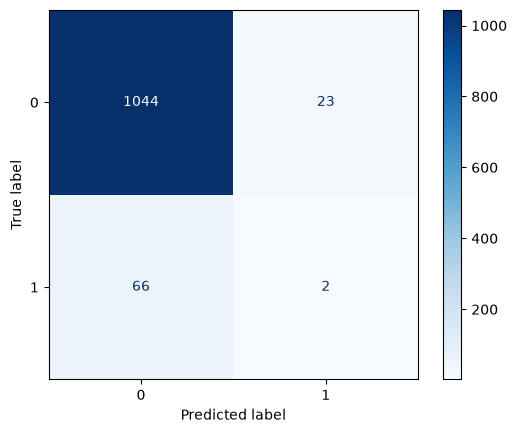

In [232]:
# Curcar PR-AUC e ROC-AUC, matriz de confusão, classification report e feature importance
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_probs = model_xgb.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, class_probs)
pr_auc = auc(recall, precision)                  # x = recall, y = precision
ap = average_precision_score(y_test, class_probs) # versão mais robusta do PR-AUC
roc_auc = roc_auc_score(y_test, class_probs)

print(f"PR-AUC: {pr_auc:.4f} | Average Precision: {ap:.4f} | linha de base: {y_test.mean():.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print(f"PR-AUC: {pr_auc:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, model_xgb.predict(X_test))
print("Matriz de Confusão:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_xgb.classes_)
disp.plot(cmap=plt.cm.Blues)

# Relatório de classificação
print("Relatório de Classificação:")
print(classification_report(y_test, model_xgb.predict(X_test)))

# Importância das features
feature_importance = model_xgb.feature_importances_
print("Importância das Features:")
for i, importance in enumerate(feature_importance):
    print(f"{X_train.columns[i]}: {importance:.4f}")

In [220]:
print(X_train.isna().sum()[lambda s: s > 0])
print(X_train.dtypes[lambda d: ~d.apply(pd.api.types.is_numeric_dtype)])

plan_tier_acct    2931
dtype: int64
Series([], dtype: object)


In [221]:
# removendo plan_tier_acct, pois tem muitos nulos.
X_train = X_train.drop(columns=["plan_tier_acct"])
X_test = X_test.drop(columns=["plan_tier_acct"])

In [222]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def lift_top10(y, p):
    t = pd.DataFrame({"y": np.asarray(y), "p": p}).nlargest(int(len(y) * 0.10), "p")
    return t["y"].mean() / np.mean(y)

treino = df_model["start_date"] < "2024-10-01"   # mesma regra usada para criar X_train/X_test

# 1) Regra: probabilidade da faixa de seats, calculada só no TREINO
faixa = pd.cut(df_model["seats_acct"], bins=bins, labels=labels)
taxa_treino = y_train.groupby(faixa[treino]).mean()
p_regra = faixa[~treino].map(taxa_treino).astype(float)

logreg = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", C=0.1, max_iter=1000))
logreg.fit(X_train, y_train)
p_log = logreg.predict_proba(X_test)[:, 1]

for nome, p in [("XGBoost", class_probs), ("Logística", p_log), ("Regra seats", p_regra)]:
    print(f"{nome:12s} ROC-AUC: {roc_auc_score(y_test, p):.3f} | AP: {average_precision_score(y_test, p):.3f} | lift top10%: {lift_top10(y_test, p):.2f}x")

XGBoost      ROC-AUC: 0.477 | AP: 0.061 | lift top10%: 0.89x
Logística    ROC-AUC: 0.501 | AP: 0.070 | lift top10%: 1.33x
Regra seats  ROC-AUC: 0.508 | AP: 0.063 | lift top10%: 1.03x


os dados não sustentam previsão individual. Três abordagens foram treinadas só com informação do dia da assinatura e validadas no tempo (treino até 2024Q3, teste em 2024Q4). Os resultados no teste foram:

XGBoost      ROC-AUC: 0.477 | AP: 0.061 | lift top10%: 0.89x
Logística    ROC-AUC: 0.501 | AP: 0.070 | lift top10%: 1.33x
Regra seats  ROC-AUC: 0.508 | AP: 0.063 | lift top10%: 1.03x
acaso        ROC-AUC: 0,50  | AP: 0,050 | lift top10%: 1.00x

*O lift da logística corresponde a ~3 casos acima do esperado, dentro do ruído.

Leitura: o efeito do tamanho da conta existe no agregado (p = 0,001), mas é pequeno demais para distinguir clientes individualmente. O salto de churn no Q4 atingiu todos os perfis de forma parecida, o que indica um problema sistêmico na entrada de novos clientes, e não um segmento específico.
Implicação: em vez de tentar prever quem vai sair, a empresa deve consertar o onboarding para todos e usar a MRR para decidir onde colocar contato humano. O modelo deve ser revisitado quando existirem dados confiáveis de ativação (uso real nos primeiros dias), que hoje faltam em 80% das assinaturas.

In [233]:
rng = np.random.default_rng(42)
yt = np.asarray(y_test)
for nome, p in [("XGBoost", class_probs), ("Logística", p_log), ("Regra seats", np.asarray(p_regra))]:
    aps = []
    for _ in range(1000):
        idx = rng.integers(0, len(yt), len(yt))
        if yt[idx].sum() > 0:
            aps.append(average_precision_score(yt[idx], p[idx]))
    print(f"{nome:12s} AP: {np.mean(aps):.3f}  IC95%: [{np.percentile(aps, 2.5):.3f}, {np.percentile(aps, 97.5):.3f}]")

XGBoost      AP: 0.064  IC95%: [0.044, 0.096]
Logística    AP: 0.075  IC95%: [0.050, 0.115]
Regra seats  AP: 0.064  IC95%: [0.046, 0.084]


Com bootstrap de 1.000 reamostragens do teste, os intervalos de confiança de 95% da Average Precision dos três modelos (XGBoost 0,044–0,096; logística 0,050–0,115; regra 0,046–0,084) se sobrepõem e incluem a linha de base de 0,060. Nenhum modelo é estatisticamente distinguível do acaso.

import os
os.makedirs("img", exist_ok=True)

# Gráfico 1: churn em 30 dias por coorte (janela fixa)
n = 30
corte = df_subscriptions["start_date"].max() - pd.Timedelta(days=n)
eleg = df_subscriptions[df_subscriptions["start_date"] <= corte].copy()
eleg["churn_30d"] = eleg["days_to_churn"] <= n
taxa_c = eleg.groupby("start_quarter")["churn_30d"].agg(["mean", "size"]).reset_index()
fig_c = px.bar(taxa_c, x="start_quarter", y="mean", text="size",
               title="% de assinaturas canceladas em até 30 dias, por coorte de início")
fig_c.update_layout(yaxis_tickformat=".1%", xaxis_title="Coorte (trimestre de início)",
                    yaxis_title="% churn em 30 dias")
fig_c.write_image("img/churn_30d_coorte.png", width=1000, height=500, scale=2)

# Gráfico 2: dose-resposta por tamanho da conta
fig_s = px.bar(resumo, x="faixa_seats", y="pct_churn_30d", text="contas",
               title="% de contas com churn em até 30 dias, por tamanho da conta")
fig_s.update_layout(yaxis_tickformat=".0%", xaxis_title="Faixa de seats da conta",
                    yaxis_title="% de contas com churn em 30 dias")
fig_s.write_image("img/churn_30d_seats.png", width=1000, height=500, scale=2)